In [1]:
from google.colab import files

uploaded = files.upload()

Saving daily_forex_rates.csv to daily_forex_rates.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
df = pd.read_csv("daily_forex_rates.csv")

In [4]:
df.head()

,currency,base_currency,currency_name,exchange_rate,date
0,ZWL,EUR,Zimbabwean Dollar,368.033231,2026-07-07
1,GHS,EUR,Ghanaian Cedi,13.002611,2026-07-07
2,HRK,EUR,Croatian Kuna,7.533834,2026-07-07
3,HNL,EUR,Honduran Lempira,30.541598,2026-07-07
4,HKD,EUR,Hong Kong Dollar,8.963850,2026-07-07


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489499 entries, 0 to 489498
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   currency       489499 non-null  object 
 1   base_currency  489499 non-null  object 
 2   currency_name  487022 non-null  object 
 3   exchange_rate  489499 non-null  float64
 4   date           489499 non-null  object 
dtypes: float64(1), object(4)
memory usage: 18.7+ MB


In [6]:
df.columns

Index(['currency', 'base_currency', 'currency_name', 'exchange_rate', 'date'], dtype='object')

In [7]:
df["currency"].unique()

array(['ZWL', 'GHS', 'HRK', 'HNL', 'HKD', 'GYD', 'GTQ', 'GNF', 'GMD',
       'GIP', 'GGP', 'HUF', 'GEL', 'GBP', 'FKP', 'FJD', 'EUR', 'ETB',
       'ERN', 'EGP', 'HTG', 'IDR', 'LBP', 'KES', 'KZT', 'KYD', 'KWD',
       'KRW', 'KPW', 'KMF', 'KHR', 'KGS', 'JPY', 'ILS', 'JOD', 'JMD',
       'JEP', 'ISK', 'IRR', 'IQD', 'INR', 'IMP', 'DZD', 'DOP', 'DKK',
       'BAM', 'BOB', 'BND', 'BMD', 'BIF', 'BHD', 'BGN', 'BDT', 'BBD',
       'AZN', 'DJF', 'AWG', 'AUD', 'ARS', 'AOA', 'ANG', 'AMD', 'ALL',
       'AFN', 'BRL', 'BSD', 'BTC', 'BTN', 'CZK', 'CVE', 'CUP', 'CUC',
       'CRC', 'COP', 'CNH', 'CNY', 'CLP', 'CLF', 'CHF', 'CDF', 'CAD',
       'BZD', 'BYR', 'BYN', 'BWP', 'LAK', 'LKR', 'SEK', 'SZL', 'TWD',
       'TTD', 'TRY', 'TOP', 'TND', 'TMT', 'TJS', 'THB', 'SYP', 'UAH',
       'SVC', 'STN', 'STD', 'SRD', 'SOS', 'SLL', 'SLE', 'SHP', 'TZS',
       'UGX', 'LRD', 'XCD', 'ZMW', 'ZMK', 'ZAR', 'YER', 'XPF', 'XOF',
       'XDR', 'XCG', 'XAU', 'USD', 'XAG', 'XAF', 'WST', 'VUV', 'VND',
       'VES', 'UZS',

WE WILL CREATE 1 FUNCTION FOR ALL THE STEPS

In [8]:
def train_currency(currency_code):

    print("=" * 60)
    print(f"Training LSTM Model for EUR -> {currency_code}")
    print("=" * 60)

    # -------------------------------------------------
    # Step 1: Filter the selected currency
    # -------------------------------------------------
    currency_df = df[df["currency"] == currency_code].copy()

    # -------------------------------------------------
    # Step 2: Data Preprocessing
    # -------------------------------------------------
    currency_df["date"] = pd.to_datetime(currency_df["date"])
    currency_df = currency_df.sort_values("date")
    currency_df = currency_df[["date", "exchange_rate"]]
    currency_df.reset_index(drop=True, inplace=True)

    # -------------------------------------------------
    # Step 3: Feature Selection
    # -------------------------------------------------
    data = currency_df[["exchange_rate"]]

    # -------------------------------------------------
    # Step 4: Normalize Data
    # -------------------------------------------------
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(data)

    # -------------------------------------------------
    # Step 5: Create Sequences
    # -------------------------------------------------
    sequence_length = 60

    X = []
    y = []

    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i,0])
        y.append(scaled_data[i,0])

    X = np.array(X)
    y = np.array(y)

    # -------------------------------------------------
    # Step 6: Train-Test Split
    # -------------------------------------------------
    train_size = int(len(X)*0.8)

    X_train = X[:train_size]
    X_test = X[train_size:]

    y_train = y[:train_size]
    y_test = y[train_size:]

    # -------------------------------------------------
    # Step 7: Reshape for LSTM
    # -------------------------------------------------
    X_train = X_train.reshape(
        X_train.shape[0],
        X_train.shape[1],
        1
    )

    X_test = X_test.reshape(
        X_test.shape[0],
        X_test.shape[1],
        1
    )

    # -------------------------------------------------
    # Step 8: Build Multi-Layer LSTM
    # -------------------------------------------------
    model = Sequential()

    model.add(
        LSTM(
            units=100,
            return_sequences=True,
            input_shape=(X_train.shape[1],1)
        )
    )

    model.add(Dropout(0.2))

    model.add(LSTM(50))

    model.add(Dropout(0.2))

    model.add(Dense(25))

    model.add(Dense(1))

    # -------------------------------------------------
    # Step 9: Compile Model
    # -------------------------------------------------
    model.compile(
        optimizer="adam",
        loss="mean_squared_error"
    )

    # -------------------------------------------------
    # Step 10: Train Model
    # -------------------------------------------------
    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test,y_test),
        verbose=1
    )

    # -------------------------------------------------
    # Step 11: Prediction
    # -------------------------------------------------
    predictions = model.predict(X_test)

    predictions = scaler.inverse_transform(predictions)

    actual = scaler.inverse_transform(
        y_test.reshape(-1,1)
    )

    # -------------------------------------------------
    # Step 12: Evaluation
    # -------------------------------------------------
    mse = mean_squared_error(actual,predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual,predictions)

    print("\nEvaluation Metrics")
    print("------------------------")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)

    # -------------------------------------------------
    # Step 13: Plot Graph
    # -------------------------------------------------
    plt.figure(figsize=(15,5))

    plt.plot(actual,label="Actual Exchange Rate")

    plt.plot(predictions,label="Predicted Exchange Rate")

    plt.title(f"EUR to {currency_code} Exchange Rate Prediction")

    plt.xlabel("Time")

    plt.ylabel("Exchange Rate")

    plt.legend()

    plt.grid(True)

    plt.show()

    # -------------------------------------------------
    # Step 14: Save Model
    # -------------------------------------------------
    model.save(f"{currency_code}_lstm_model.keras")

    print(f"\n{currency_code} model saved successfully!")

TRAINING USD

Training LSTM Model for EUR -> USD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 0.0063 - val_loss: 1.7200e-04
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0018 - val_loss: 2.2398e-04
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - loss: 0.0014 - val_loss: 1.6619e-04
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - loss: 0.0013 - val_loss: 2.3027e-04
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - loss: 0.0010 - val_loss: 3.1614e-04
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - loss: 9.1461e-04 - val_loss: 1.8794e-04
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - loss: 7.9193e-04 - val_loss: 1.3170e-04
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - loss: 7.7654e-04 - val_loss: 1.4681e-04
Epoch 9/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - loss: 7.1341e-04 - val_loss: 1.1327e-04
Epoch 10/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - loss: 6.4674e-04 - val_loss: 1.2396e-04
Epoch 11/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - lo

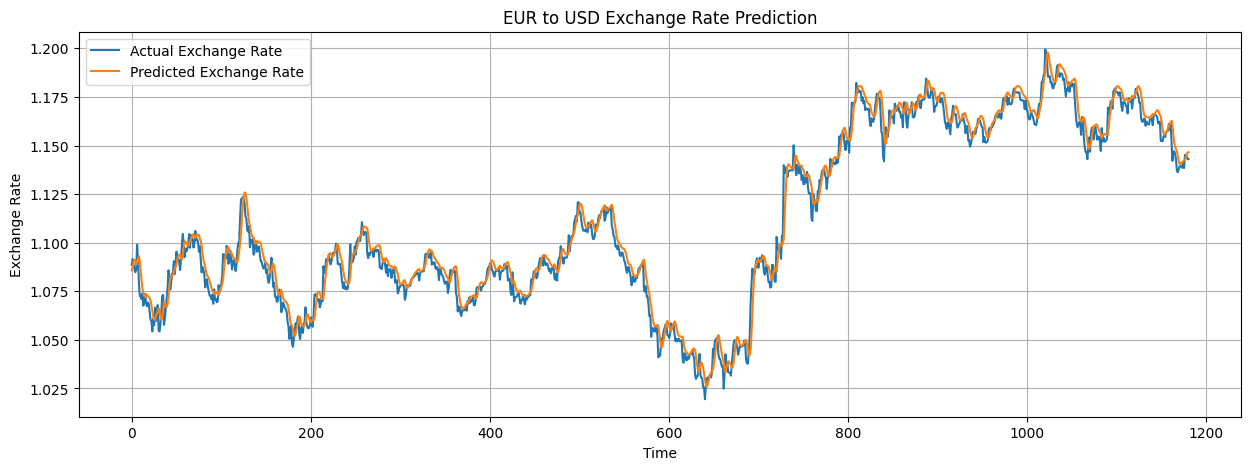


USD model saved successfully!


In [9]:
train_currency("USD")

TRAINING GBP


Training LSTM Model for EUR -> GBP
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 0.0104 - val_loss: 0.0012
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - loss: 0.0027 - val_loss: 4.1773e-04
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - loss: 0.0021 - val_loss: 5.2657e-04
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - loss: 0.0019 - val_loss: 1.8342e-04
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - loss: 0.0017 - val_loss: 1.6166e-04
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - loss: 0.0014 - val_loss: 1.7338e-04
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - loss: 0.0013 - val_loss: 2.4298e-04
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - loss: 0.0011 - val_loss: 3.1054e-04
Epoch 9/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0010 - val_loss: 1.3387e-04
Epoch 10/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 9.5246e-04 - val_loss: 1.7027e-04
Epoch 11/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - loss: 9.3376e-04 - val_loss: 1.12

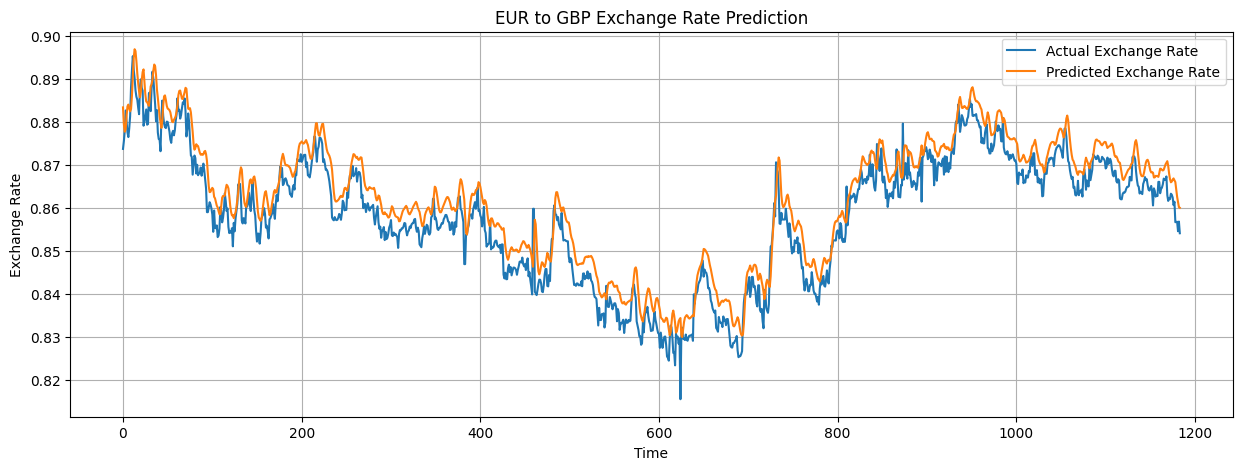


GBP model saved successfully!


In [10]:
train_currency("GBP")

TRAINING INR

Training LSTM Model for EUR -> INR
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0058 - val_loss: 4.5460e-04
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0013 - val_loss: 7.0994e-04
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0010 - val_loss: 4.7486e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 8.9832e-04 - val_loss: 4.1219e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 8.2940e-04 - val_loss: 3.7187e-04
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 7.3092e-04 - val_loss: 7.1356e-04
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - loss: 7.0724e-04 - val_loss: 3.4181e-04
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 5.9047e-04 - val_loss: 6.2359e-04
Epoch 9/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 5.3524e-04 - val_loss: 3.3879e-04
Epoch 10/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - loss: 4.8997e-04 - val_loss: 6.4080e-04
Epoch 11/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 4.8000e-04 - val_loss: 3.154

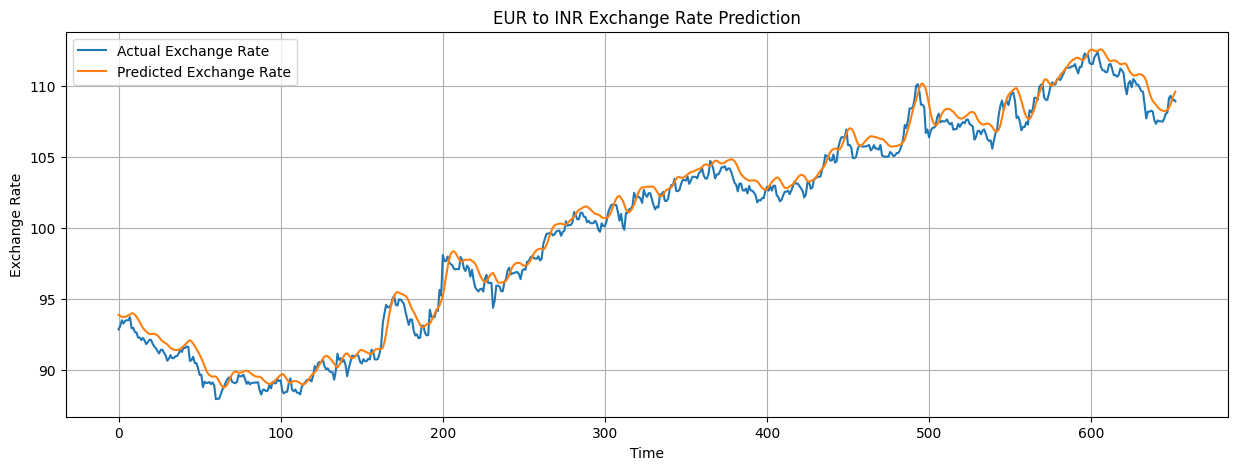


INR model saved successfully!


In [11]:
train_currency("INR")